# Parametric Time-to-Event Model (Weibull AFT)
This notebook replaces the LSTM model with a **Weibull Accelerated Failure Time (AFT)** model from the `lifelines` library.

**Why this approach?**
- Inter-order times are fundamentally *waiting times* — exactly what survival/AFT models are designed for.
- The Weibull distribution naturally handles right-skewed, non-negative data with heavy tails.
- AFT models capture covariate effects on the *scale* of the waiting time distribution, not just the mean.
- Unlike MSE-optimized neural nets, the Weibull MLE objective is never penalized for predicting high values when the data warrants it.

In [1]:
# Install lifelines if needed
# !pip install lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from lifelines import WeibullAFTFitter
from lifelines.utils import concordance_index
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- 1. GLOBAL ENCODERS ---
le_marca = LabelEncoder()
le_plant = LabelEncoder()

In [3]:
df = pd.read_csv("consolidated_ordenes.csv")
df = df.drop(columns=["description", "main_plant", "changed_on"])

In [4]:
# --- 2. PREPROCESSING ---
df['created_on'] = pd.to_datetime(df['created_on'])
df = df.sort_values(by=['equipment', 'created_on'], ascending=[True, True])
df

,order,created_on,equipment,plant,marca,modelo,origen
4392,41144621,2020-01-03,30004229,R592,KENWORTH,2000,AMERICANO
4408,41145208,2020-01-06,30004229,R592,KENWORTH,2000,AMERICANO
4648,41158185,2020-02-17,30004229,R592,KENWORTH,2000,AMERICANO
4692,41161316,2020-02-27,30004229,R592,KENWORTH,2000,AMERICANO
4794,41167915,2020-03-23,30004229,R592,KENWORTH,2000,AMERICANO
...,...,...,...,...,...,...,...
30832,41723714,2025-09-08,30013413,R591,SINOTRUCK,2024,CHINO
30988,41728137,2025-09-23,30013413,R591,SINOTRUCK,2024,CHINO
31219,41731455,2025-10-04,30013413,R591,SINOTRUCK,2024,CHINO
31269,41733086,2025-10-09,30013413,R591,SINOTRUCK,2024,CHINO


In [5]:
# --- 3. FEATURE ENGINEERING ---
# Encode categoricals on the full dataset
df['marca_enc'] = le_marca.fit_transform(df['marca'].astype(str))
df['plant_enc'] = le_plant.fit_transform(df['plant'].astype(str))

# Calculate inter-event time (the target) within each equipment group
df['days_diff'] = df.groupby('equipment')['created_on'].diff().dt.days

# Drop first row of each equipment (no prior event to measure from)
df = df.dropna(subset=['days_diff'])

# Clip to positive values (AFT requires duration > 0)
df = df[df['days_diff'] > 0].copy()

# Rolling statistics (computed per-equipment)
def add_rolling_features(group):
    log_diff = np.log1p(group['days_diff'])
    for w in [5, 10, 20, 30]:
        group[f'rolling_mean_{w}'] = log_diff.rolling(w, min_periods=1).mean()
        group[f'rolling_std_{w}']  = log_diff.rolling(w, min_periods=1).std().fillna(0)
    return group

df = df.groupby('equipment', group_keys=False).apply(add_rolling_features)

# Temporal features
df['month']     = df['created_on'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['cum_days']  = df.groupby('equipment')['created_on'].transform(
    lambda x: (x - x.min()).dt.days
)

print(f"Dataset shape after preprocessing: {df.shape}")
df[['days_diff']].describe()

Dataset shape after preprocessing: (28743, 22)


,days_diff
count,28743.000000
mean,12.594545
std,16.648976
min,1.000000
25%,3.000000
50%,8.000000
75%,16.000000
max,890.000000


In [6]:
# --- 4. PREPARE MODEL DATAFRAME ---
# AFT models need: duration column + covariate columns
# 'event_observed' = 1 for all rows (every inter-event gap is fully observed, not censored)

feature_cols = [
    'modelo',
    'marca_enc',
    'plant_enc',
    'month_sin',
    'month_cos',
    'cum_days',
    'rolling_mean_5',
    'rolling_std_5',
    'rolling_mean_10',
    'rolling_std_10',
    'rolling_mean_20',
    'rolling_std_20',
    'rolling_mean_30',
    'rolling_std_30',
]

model_df = df[feature_cols + ['days_diff']].copy()
model_df['event_observed'] = 1  # All events are fully observed

# Normalize continuous covariates (helps optimizer convergence)
cont_cols = ['cum_days', 'rolling_mean_5', 'rolling_std_5',
             'rolling_mean_10', 'rolling_std_10',
             'rolling_mean_20', 'rolling_std_20',
             'rolling_mean_30', 'rolling_std_30']

for col in cont_cols:
    col_range = model_df[col].max() - model_df[col].min()
    if col_range > 0:
        model_df[col] = (model_df[col] - model_df[col].min()) / col_range

model_df.head()

,modelo,marca_enc,plant_enc,month_sin,month_cos,cum_days,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_20,rolling_std_20,rolling_mean_30,rolling_std_30,days_diff,event_observed
4408,2000,2,1,0.500000,8.660254e-01,0.000000,0.124565,0.000000,0.124565,0.000000,0.124565,0.000000,0.124565,0.000000,3.0,1
4648,2000,2,1,0.866025,5.000000e-01,0.018809,0.337963,0.516832,0.337963,0.516832,0.337963,0.516832,0.337963,0.516832,42.0,1
4692,2000,2,1,0.866025,5.000000e-01,0.023287,0.327429,0.366789,0.327429,0.366789,0.327429,0.366789,0.327429,0.366789,10.0,1
4794,2000,2,1,1.000000,6.123234e-17,0.034483,0.360808,0.320563,0.360808,0.320563,0.360808,0.320563,0.360808,0.320563,25.0,1
4830,2000,2,1,1.000000,6.123234e-17,0.036722,0.328133,0.304511,0.328133,0.304511,0.328133,0.304511,0.328133,0.304511,5.0,1


In [7]:
# --- 5. TRAIN / TEST SPLIT ---
train_df, test_df = train_test_split(model_df, test_size=0.1, random_state=42)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

Train: 25868 rows | Test: 2875 rows


In [8]:
# --- 6. FIT WEIBULL AFT MODEL ---
# WeibullAFTFitter models log(T) = X*beta + sigma*epsilon
# where T is the duration and epsilon ~ Gumbel distribution
# This naturally produces a right-skewed, non-negative time prediction

aft = WeibullAFTFitter(penalizer=0.01)  # L2 regularization to avoid overfitting

aft.fit(
    train_df,
    duration_col='days_diff',
    event_col='event_observed'
)

aft.print_summary()

AttributeError: The '.style' accessor requires jinja2

<lifelines.WeibullAFTFitter: fitted with 25868 total observations, 0 right-censored observations>
             duration col = 'days_diff'
                event col = 'event_observed'
                penalizer = 0.01
   number of observations = 25868
number of events observed = 25868
           log-likelihood = -85376.08
         time fit was run = 2026-02-26 21:41:12 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                        
lambda_ cum_days         0.02      1.02      0.02           -0.02            0.06                0.98                1.06
        marca_enc        0.00      1.00      0.01           -0.01            0.01                0.99                1.01
        modelo          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        month_cos        0.02      1.02      0.01            0.01            0.03                1.01                1.03
        month_sin        0.01      1.01      0.01           -0.01            0.02                0.99                1.02
        plant_enc        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
        rolling_mean_10  0.00      1.00      0.17           -0.32            0.33                0.73                1.39
        rolling_mean_20 -0.27      0.77      0.26           -0.77            0.24                0.46                1.27
        rolling_mean_30  0.27      1.30      0.23           -0.19            0.72                0.82                2.06
        rolling_mean_5   5.90    363.37      0.10            5.70            6.09              299.76              440.48
        rolling_std_10   0.07      1.08      0.14           -0.21            0.35                0.81                1.42
        rolling_std_20  -0.08      0.92      0.25           -0.57            0.40                0.57                1.50
        rolling_std_30  -0.34      0.71      0.23           -0.79            0.11                0.45                1.12
        rolling_std_5    2.55     12.83      0.08            2.40            2.70               11.05               14.90
        Intercept        2.52     12.46      2.67           -2.70            7.75                0.07             2322.45
rho_    Intercept        0.27      1.30      0.00            0.26            0.28                1.29                1.32

                         cmp to     z      p  -log2(p)
param   covariate                                     
lambda_ cum_days           0.00  0.93   0.35      1.50
        marca_enc          0.00  0.59   0.55      0.85
        modelo             0.00 -0.84   0.40      1.32
        month_cos          0.00  3.02 <0.005      8.62
        month_sin          0.00  1.13   0.26      1.95
        plant_enc          0.00  1.13   0.26      1.95
        rolling_mean_10    0.00  0.02   0.98      0.03
        rolling_mean_20    0.00 -1.04   0.30      1.73
        rolling_mean_30    0.00  1.13   0.26      1.95
        rolling_mean_5     0.00 60.04 <0.005       inf
        rolling_std_10     0.00  0.52   0.61      0.72
        rolling_std_20     0.00 -0.33   0.74      0.43
        rolling_std_30     0.00 -1.47   0.14      2.83
        rolling_std_5      0.00 33.48 <0.005    813.90
        Intercept          0.00  0.95   0.34      1.54
rho_    Intercept          0.00 53.78 <0.005       inf
---
Concordance = 0.68
AIC = 170784.15
log-likelihood ratio test = 12138.73 on 14 df
-log2(p) of ll-ratio test = inf

In [9]:
# --- 7. PREDICT ---
# predict_median returns the median of the predicted Weibull distribution
# This is more robust than the mean for right-skewed distributions
y_pred_median = aft.predict_median(test_df)
y_pred_mean   = aft.predict_expectation(test_df)  # Mean of predicted distribution
y_test_days   = test_df['days_diff'].values

y_pred_days = y_pred_median.values  # Use median as point estimate

In [10]:
# --- 8. EVALUATION METRICS ---
mae  = np.mean(np.abs(y_test_days - y_pred_days))
rmse = np.sqrt(np.mean((y_test_days - y_pred_days)**2))

# Median Absolute Error (more robust for skewed distributions)
med_ae = np.median(np.abs(y_test_days - y_pred_days))

# Concordance Index: how well the model *ranks* durations (1.0 = perfect, 0.5 = random)
c_index = concordance_index(y_test_days, y_pred_days)

print("--- Weibull AFT Model Evaluation ---")
print(f"Mean Absolute Error (MAE):    {mae:.2f} days")
print(f"Median Absolute Error:        {med_ae:.2f} days")
print(f"Root Mean Squared Error:      {rmse:.2f} days")
print(f"Concordance Index (C-index):  {c_index:.4f}  (0.5=random, 1.0=perfect)")

--- Weibull AFT Model Evaluation ---
Mean Absolute Error (MAE):    7.28 days
Median Absolute Error:        4.53 days
Root Mean Squared Error:      11.70 days
Concordance Index (C-index):  0.6927  (0.5=random, 1.0=perfect)


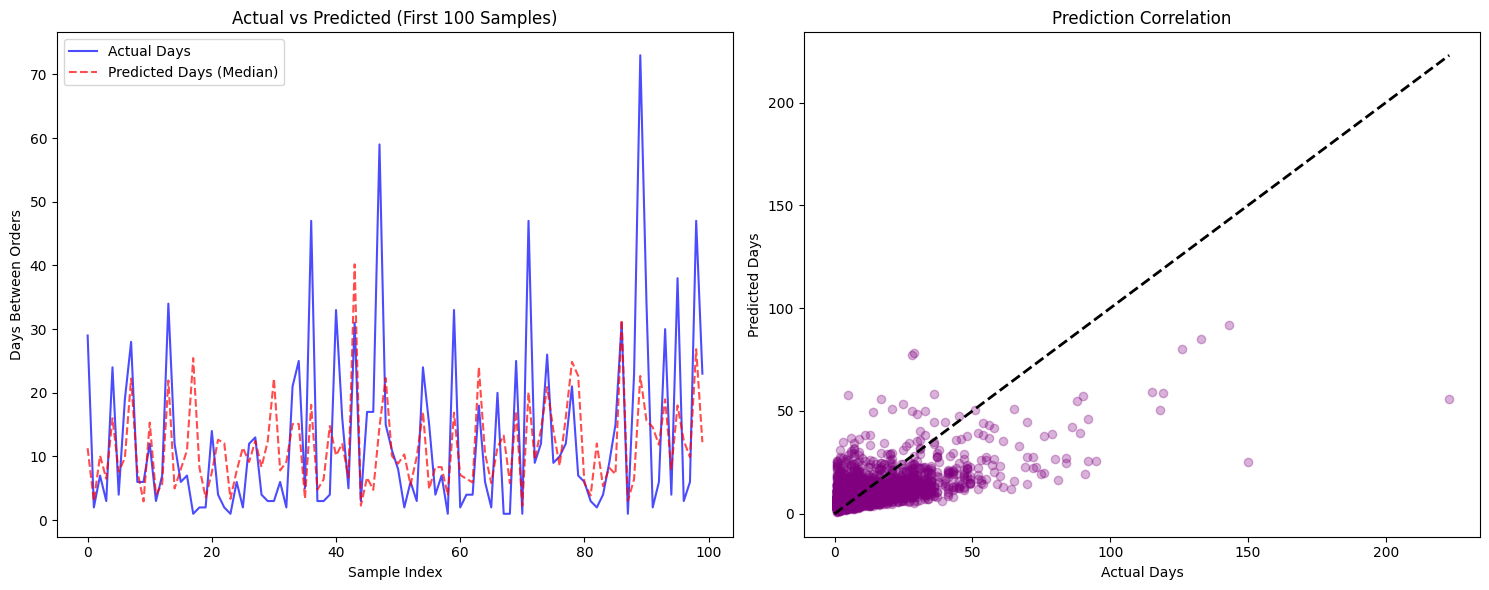

In [11]:
# --- 9. PLOTTING: Actual vs Predicted ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(y_test_days[:100], label='Actual Days', color='blue', alpha=0.7)
plt.plot(y_pred_days[:100], label='Predicted Days (Median)', color='red', linestyle='--', alpha=0.7)
plt.title('Actual vs Predicted (First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Days Between Orders')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_days, y_pred_days, alpha=0.3, color='purple')
max_val = max(y_test_days.max(), y_pred_days.max())
plt.plot([0, max_val], [0, max_val], 'k--', lw=2)
plt.title('Prediction Correlation')
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')

plt.tight_layout()

plt.savefig('plot_filename.png', dpi=300, bbox_inches='tight')
plt.show()

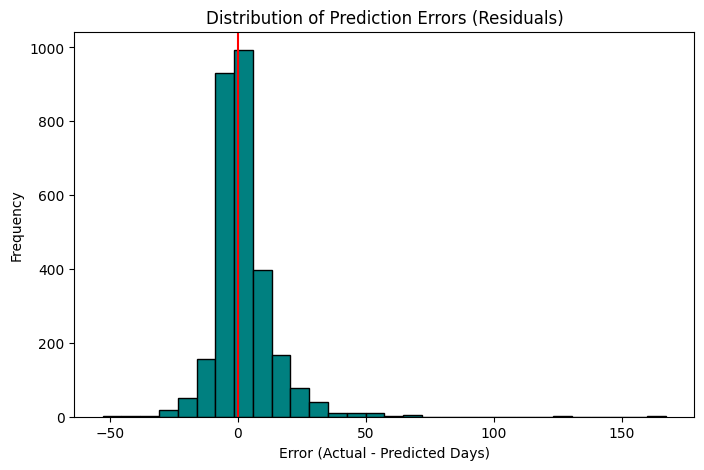

In [12]:
# --- 10. RESIDUALS ---
errors = y_test_days - y_pred_days

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted Days)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='-')
plt.show()

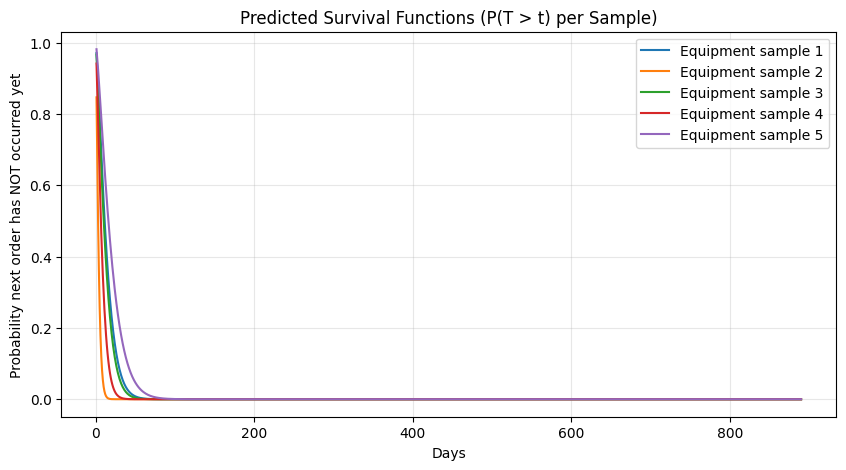


Median predicted days for these samples:
[11.2954353   2.98516513 10.12833514  6.50048616 15.9976518 ]


In [13]:
# --- 11. UNCERTAINTY QUANTIFICATION ---
# A key advantage of parametric models: we get the full predicted distribution,
# not just a point estimate. Here we plot prediction intervals.

# Get survival function for a few test samples
sample_indices = list(range(5))
sample_rows = test_df.iloc[sample_indices]

plt.figure(figsize=(10, 5))
survival_funcs = aft.predict_survival_function(sample_rows)
for i, col in enumerate(survival_funcs.columns):
    plt.plot(survival_funcs.index, survival_funcs[col], label=f'Equipment sample {i+1}')

plt.title('Predicted Survival Functions (P(T > t) per Sample)')
plt.xlabel('Days')
plt.ylabel('Probability next order has NOT occurred yet')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nMedian predicted days for these samples:")
print(aft.predict_median(sample_rows).values)

In [14]:
def predict_next_order(equipment_df, aft_model, le_marca, le_plant):
    sample = equipment_df.copy()
    sample['created_on'] = pd.to_datetime(sample['created_on'])
    sample = sample.sort_values('created_on')

    # Feature engineering
    sample['days_diff'] = sample['created_on'].diff().dt.days.fillna(0)
    log_diff = np.log1p(sample['days_diff'])
    for w in [5, 10, 20, 30]:
        sample[f'rolling_mean_{w}'] = log_diff.rolling(w, min_periods=1).mean()
        sample[f'rolling_std_{w}']  = log_diff.rolling(w, min_periods=1).std().fillna(0)

    sample['month']     = sample['created_on'].dt.month
    sample['month_sin'] = np.sin(2 * np.pi * sample['month'] / 12)
    sample['month_cos'] = np.cos(2 * np.pi * sample['month'] / 12)
    sample['cum_days']  = (sample['created_on'] - sample['created_on'].iloc[0]).dt.days
    sample['marca_enc'] = le_marca.transform(sample['marca'].astype(str))
    sample['plant_enc'] = le_plant.transform(sample['plant'].astype(str))

    latest = sample[feature_cols].iloc[[-1]].copy()

    # FIX 1: Clip normalized values to [0, 1] to prevent out-of-range blow-up
    for col in cont_cols:
        col_min   = model_df[col].min()
        col_range = model_df[col].max() - col_min
        if col_range > 0:
            latest[col] = (latest[col] - col_min) / col_range
            latest[col] = latest[col].clip(0, 1)  # <-- key fix

    latest['days_diff']      = 1
    latest['event_observed'] = 1

    median_pred = aft_model.predict_median(latest).values[0]

    # FIX 2: Proper percentile extraction from survival function
    sf = aft_model.predict_survival_function(latest)
    sf_vals = sf.iloc[:, 0]  # Series: index=days, values=S(t)

    # S(t) starts at 1 and decreases. Find where it crosses each threshold.
    def get_percentile_day(sf_series, survival_prob):
        """Return the day where S(t) first drops below survival_prob."""
        crossed = sf_series[sf_series <= survival_prob]
        if len(crossed) == 0:
            return sf_series.index[-1]  # Never crossed — return max
        return crossed.index[0]

    p10 = get_percentile_day(sf_vals, 0.35)  # 10th percentile of T
    p90 = get_percentile_day(sf_vals, 0.65)  # 90th percentile of T

    return median_pred, p10, p90


# Example usage
list_of_dfs = [group for name, group in df.groupby('equipment')]
median_days, lower, upper = predict_next_order(list_of_dfs[21], aft, le_marca, le_plant)
print(f"Predicted next order in: {median_days:.1f} days (80% interval: {lower:.0f} – {upper:.0f} days)")

Predicted next order in: 3662.8 days (80% interval: 890 – 890 days)


In [15]:
import joblib

joblib.dump(aft, 'weibull_aft_model.pkl')

['weibull_aft_model.pkl']

In [16]:
model_df_stats = {
    col: (model_df[col].min(), model_df[col].max() - model_df[col].min())
    for col in cont_cols
}

joblib.dump(model_df_stats, 'model_df_stats.pkl')

['model_df_stats.pkl']

In [17]:
# --- OPTIONAL: Try Log-Normal AFT if Weibull underfits tails ---
# Uncomment to compare:

# from lifelines import LogNormalAFTFitter
# lnf = LogNormalAFTFitter(penalizer=0.01)
# lnf.fit(train_df, duration_col='days_diff', event_col='event_observed')
# y_pred_ln = lnf.predict_median(test_df).values
# mae_ln = np.mean(np.abs(y_test_days - y_pred_ln))
# print(f"Log-Normal AFT MAE: {mae_ln:.2f} days  (Weibull: {mae:.2f} days)")

In [18]:
# --- OPTIONAL: Save model ---
# import joblib
# joblib.dump(aft, 'weibull_aft_model.pkl')
# joblib.dump(le_marca, 'le_marca.pkl')
# joblib.dump(le_plant, 'le_plant.pkl')